In [1]:
import numpy as np
import pandas as pd 
import cmath 
import scipy.special as sp
import scipy.signal as spg
import scipy.constants as const
import matplotlib.pyplot as plt

### Comparison between Jackson's equation predictions and the COMSOL predictions, based on equation for dielectric cylinder, 

where the TM modes can be found by the solution to: 

$$ 
\omega_{m,n,p} = \frac{c}{\sqrt{\mu\epsilon}} \sqrt{\frac{x_{m,n}^2}{R^2} + \frac{p^2 \pi^2}{d^2}}
$$

and TE modes can be found by the solution to: 

$$ 
\omega_{m,n,p} = \frac{c}{\sqrt{\mu\epsilon}} \sqrt{\frac{x\prime_{m,n}^2}{R^2} + \frac{p^2 \pi^2}{d^2}}
$$

Realistically, these equations cannot be validly predictive of our alumina disk because they assume perfect electrically conducting walls (we have a dielectric-air boundary), a field confinement dynamic of standing waves in a metal box (we have TIR along caustic), a uniform permittivity (again, air-dielectric interaction important), Bessel functions enforce boundary at the PEC wall while in reality there is an exponential decay beyond a certain point (caustic), 

NOTE: for epsilon_r, using number based on an average of Keith's measurements of index of refraction on disk: 

$\bar n = (3.1238 + 3.12429 + 3.12415)/3 = 3.12408$ 

$3.12408^2 = 9.7598758464$ <-- using this for $\epsilon_r$

In [8]:
# for TM 
def bessel_roots(m, n): 
    roots = sp.jn_zeros(m, n)
    return roots 

# for TE
def bessel_deriv_roots(m, n):
    roots = sp.jnp_zeros(m, n)
    return roots

def omega_mnp(x_mn, mu = 1, epsilon = 9.6, p = 0, d = 0.0254, R = 0.0762):
    omega = (c/np.sqrt(mu*epsilon)) * (np.sqrt(((x_mn**2)/(R**2)) + (p**2*np.pi**2)/d**2))
    return omega

def omega_mnp_freq_GHz_solver(omega):
    freq = omega/(2*np.pi)
    freq_GHz = freq/(10**9)
    return freq_GHz

def freq_solver_omega_GHz(x_mn, mu = 1, epsilon = 9.6, p = 0, d = 0.0254, R = 0.0762):
    omega = (c/np.sqrt(mu*epsilon)) * (np.sqrt(((x_mn**2)/(R**2)) + (p**2*np.pi**2)/d**2))
    freq = omega/(2*np.pi) # Hz
    freq_GHz = freq/(10**9) # GHz
    return freq_GHz

def bessel_freq_solver_omega_GHz(m, n, mu = 1, epsilon = 9.8, p = 0, d = 0.0254, R = 0.0762):
    X_mn = bessel_deriv_roots(m, n)[0]
    omega = (c/np.sqrt(mu*epsilon)) * (np.sqrt(((X_mn**2)/(R**2)) + (p**2*np.pi**2)/d**2))
    freq = omega/(2*np.pi) # Hz
    freq_GHz = freq/(10**9) # GHz
    return freq_GHz

# function to do whole thing

def bessel_omega_freq_solver(mode_kind, num_lobes, p_TE=1, mu = 1, 
                             epsilon = 9.7, d = 0.02542957, 
                             R = 0.07622, N = 1, n = 0): # epsilon = 9.7598758464 D = 152.44 mm # d = 0.02542957, R = 0.07622
    # define constants
    m = int(num_lobes // 2)
    
    if mode_kind == 'TM': # solve bessel and define p for transverse magnetic (TM)
        x_mn = bessel_roots(m,N)[n]
        p = 0
    if mode_kind == 'TE': # solve bessel and define p for transverse electric (TE) 
        x_mn = bessel_deriv_roots(m,N)[n]
        p = p_TE

    # calculate omega_mnp
    omega_mnp = (c/np.sqrt(mu*epsilon)) * (np.sqrt(((x_mn**2)/(R**2)) + (p**2*np.pi**2)/d**2))
    freq = omega_mnp/(2*np.pi) # Hz
    freq_GHz = freq/(10**9) # GHz

    return freq_GHz

def get_TE_TM_m_p(N_m, p_TE=1): 
    m_array = []
    TM_freqs = []
    TE_freqs = []
    for i in range(0, N_m): 
        TM_freq = bessel_omega_freq_solver('TM', num_lobes = i*2)
        TE_freq = bessel_omega_freq_solver('TE', num_lobes = i*2, p_TE=p_TE)
        m_array.append(i)
        TM_freqs.append(TM_freq)
        TE_freqs.append(TE_freq)
    eigenfreqs = {'m': m_array, 'TE': TE_freqs, 'TM': TM_freqs}
    eigen_m_table = pd.DataFrame(eigenfreqs)
    return eigen_m_table


# ------ constants --------

c = const.c

In [9]:
# see if the shift difference between the COMSOL and the jackson formula is uniform or not

In [12]:
test_TE = get_TE_TM_m_p(40, p_TE=1)
test_TE

,m,TE,TM
0,0,2.043328,0.483359
1,1,1.928471,0.770155
2,2,1.989700,1.032236
3,3,2.072461,1.282383
4,4,2.173566,1.525222
5,5,2.290171,1.763028
6,6,2.419766,1.997112
7,7,2.560193,2.228309
8,8,2.709632,2.457187
9,9,2.866572,2.684152


Bring in the eigenvalue solver for isolated disk: 

In [ ]:
Efreq_cf2p5 = pd.read_csv('/Users/leayamashiro/AliCPT/whispering_gallery/wgm_code/eigenCSV/alumina_eigenfreqs_center2p5_n109.csv', skiprows=4)
Efreq_cf3p5 = pd.read_csv('/Users/leayamashiro/AliCPT/whispering_gallery/wgm_code/eigenCSV/alumina_eigenfreqs_center3p5_n109.csv', skiprows=4)
Efreq_cf4p0 = pd.read_csv('/Users/leayamashiro/AliCPT/whispering_gallery/wgm_code/eigenCSV/alumina_eigenfreqs_center4_n109.csv', skiprows=4)
Efreq_cf4p5 = pd.read_csv('/Users/leayamashiro/AliCPT/whispering_gallery/wgm_code/eigenCSV/alumina_eigenfreqs_centerfreq4p5GHz_n109.csv', skiprows=4)

In [4]:
def fix_csv(file): 
    
    # Define a function to convert string representation to complex number
    def convert_to_j(x):
        if isinstance(x, str):  # Only try to convert if it's a string
            try:
                return x.replace('i', 'j')  # Replace 'i' with 'j' for Python compatibility
            except ValueError:
                return None  # Return None for invalid values (if any)
        else:
            return x  # If it's already a number (e.g., float), return it unchanged
        
    file['% Eigenfrequency (GHz)'] = file['% Eigenfrequency (GHz)'].apply(convert_to_j) # convert i to j for column 
    file['% Eigenfrequency (GHz)'] = file['% Eigenfrequency (GHz)'].apply(complex)
    file[['Frequency (GHz)', 'Quality factor (1)']] = file[['Frequency (GHz)', 'Quality factor (1)']].apply(pd.to_numeric, errors='coerce')

    file['Eigenfreq_Real'] = file['% Eigenfrequency (GHz)'].apply(lambda x: x.real)
    file['Eigenfreq_Imag'] = file['% Eigenfrequency (GHz)'].apply(lambda x: x.imag)

    return file

    

In [6]:
Efreq_cf2p5 = fix_csv(pd.read_csv('/Users/leayamashiro/AliCPT/whispering_gallery/wgm_code/eigenCSV/alumina_eigenfreqs_center2p5_n109.csv', skiprows=4))
Efreq_cf3p5 = fix_csv(pd.read_csv('/Users/leayamashiro/AliCPT/whispering_gallery/wgm_code/eigenCSV/alumina_eigenfreqs_center3p5_n109.csv', skiprows=4))
Efreq_cf4p0 = fix_csv(pd.read_csv('/Users/leayamashiro/AliCPT/whispering_gallery/wgm_code/eigenCSV/alumina_eigenfreqs_center4_n109.csv', skiprows=4))
Efreq_cf4p5 = fix_csv(pd.read_csv('/Users/leayamashiro/AliCPT/whispering_gallery/wgm_code/eigenCSV/alumina_eigenfreqs_centerfreq4p5GHz_n109.csv', skiprows=4))

In [19]:
Efreq_cf2p5

,% Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Eigenfreq_Real,Eigenfreq_Imag
0,1.774520+0.185648j,1.774520,4.779254,1.774520,0.185648
1,1.774545+0.185653j,1.774545,4.779191,1.774545,0.185653
2,1.787684+0.277842j,1.787684,3.217086,1.787684,0.277842
3,1.808136+0.051100j,1.808136,17.691991,1.808136,0.051100
4,1.808156+0.051104j,1.808156,17.690805,1.808156,0.051104
...,...,...,...,...,...
213,3.252775+0.002672j,3.252775,608.587313,3.252775,0.002672
214,3.252870+0.002675j,3.252870,607.944392,3.252870,0.002675
215,3.257093+0.069987j,3.257093,23.269208,3.257093,0.069987
216,3.257284+0.069973j,3.257284,23.275194,3.257284,0.069973


In [20]:
eigens_combined = pd.concat([Efreq_cf2p5, Efreq_cf3p5, Efreq_cf4p0, Efreq_cf4p5], ignore_index=True)

In [21]:
eigens_combined

,% Eigenfrequency (GHz),Frequency (GHz),Quality factor (1),Eigenfreq_Real,Eigenfreq_Imag
0,1.774520+0.185648j,1.774520,4.779254,1.774520,0.185648
1,1.774545+0.185653j,1.774545,4.779191,1.774545,0.185653
2,1.787684+0.277842j,1.787684,3.217086,1.787684,0.277842
3,1.808136+0.051100j,1.808136,17.691991,1.808136,0.051100
4,1.808156+0.051104j,1.808156,17.690805,1.808156,0.051104
...,...,...,...,...,...
867,4.885231+0.000019j,4.885231,128349.817252,4.885231,0.000019
868,4.887611+0.000019j,4.887611,125339.256085,4.887611,0.000019
869,4.890677+0.000022j,4.890677,109926.110678,4.890677,0.000022
870,4.892313+0.000024j,4.892313,101142.183646,4.892313,0.000024


In [24]:
def find_plot_Q_peaks_theory(Q_freq_data, n_peaks):
    # clean up work for TE doubles in Q1to5
    Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)
    # Step 3: Drop duplicates, keeping the first occurrence
    Qfac_all = Q_freq_data.drop_duplicates(subset='Freq rounded', keep='first')
    Q_peaks, _ = spg.find_peaks(Qfac_all['Quality factor (1)'])
    Q_peak_freqs = Qfac_all['Frequency (GHz)'].iloc[Q_peaks]
    Q_peak_Qs = Qfac_all['Quality factor (1)'].iloc[Q_peaks]
    peak_dict = {'freqs': Q_peak_freqs, 'Q': Q_peak_Qs}
    peaks = pd.DataFrame(peak_dict).sort_values('Q', ascending=False).reset_index(inplace=False)
    top_peaks = peaks.iloc[0:n_peaks]

    plt.figure(figsize = (15,10))
    # plot with peaks labeled
    plt.plot(Qfac_all['Frequency (GHz)'], Qfac_all['Quality factor (1)'])
    plt.xlabel('Freq (GHz)')
    plt.ylabel('Q factor')
    plt.title('Q Factor vs. Eigenfrequency')

    for i in range(len(top_peaks)):
        plt.scatter(top_peaks['freqs'].loc[i], top_peaks['Q'].loc[i], 
                    label = f'({top_peaks["freqs"][i]} GHz, {top_peaks["Q"][i]})')
    plt.legend()

    return Qfac_all, top_peaks

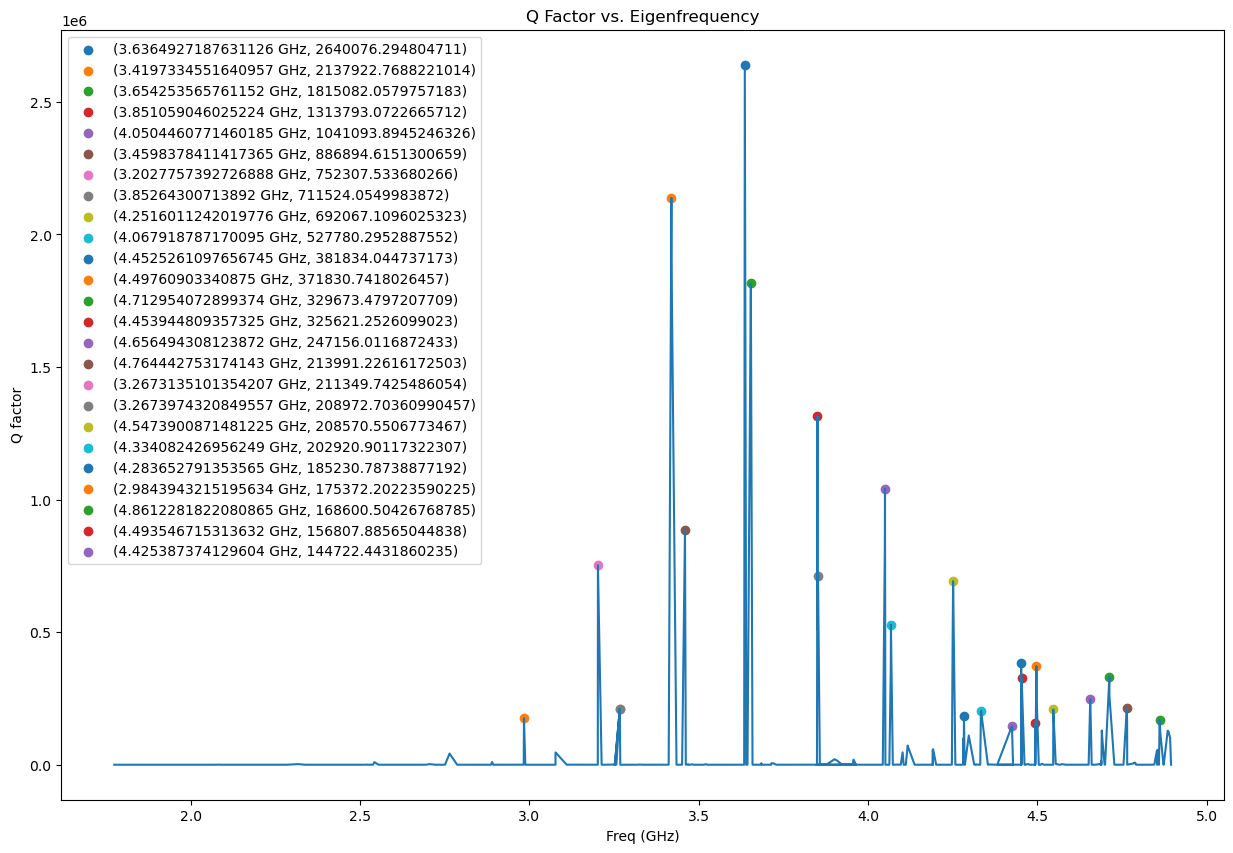

In [27]:
Q_factor_data, peak_modes = find_plot_Q_peaks_theory(eigens_combined, n_peaks = 25)

In [28]:
peak_modes.sort_values(['freqs'], ascending=True)

,index,freqs,Q
21,172,2.984394,1.753722e+05
6,207,3.202776,7.523075e+05
16,217,3.267314,2.113497e+05
17,256,3.267397,2.089727e+05
1,290,3.419733,2.137923e+06
5,297,3.459838,8.868946e+05
0,350,3.636493,2.640076e+06
2,355,3.654254,1.815082e+06
3,409,3.851059,1.313793e+06
7,412,3.852643,7.115241e+05


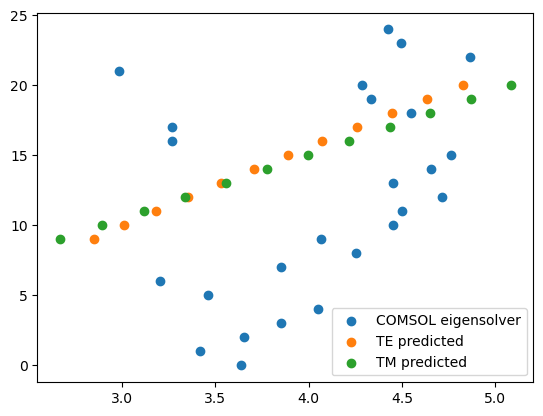

In [66]:
plt.scatter(peak_modes['freqs'], peak_modes.index, label = 'COMSOL eigensolver')
plt.scatter(test_TE['TE'][9:21], test_TE[9:21].index, label = 'TE predicted')
plt.scatter(test_TE['TM'][9:21], test_TE[9:21].index, label = 'TM predicted')
plt.legend()

In [41]:
plt.axvline?

Signature: plt.axvline(x=0, ymin=0, ymax=1, **kwargs)
Docstring:
Add a vertical line across the Axes.

Parameters
----------
x : float, default: 0
    x position in data coordinates of the vertical line.

ymin : float, default: 0
    Should be between 0 and 1, 0 being the bottom of the plot, 1 the
    top of the plot.

ymax : float, default: 1
    Should be between 0 and 1, 0 being the bottom of the plot, 1 the
    top of the plot.

Returns
-------
`~matplotlib.lines.Line2D`

Other Parameters
----------------
**kwargs
    Valid keyword arguments are `.Line2D` properties, except for
    'transform':

    Properties:
    agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
    alpha: scalar or None
    animated: bool
    antialiased or aa: bool
    clip_box: `.Bbox`
    clip_on: bool
    clip_path: Patch or (Path, Transform) or None
    color or c: color
    dash_capstyle

In [48]:
test_TE['TE'][9:21].index

RangeIndex(start=9, stop=21, step=1)

In [69]:
Q1to10_CT9p8_newdim = pd.read_csv('/Users/leayamashiro/whispering_gallery_MAIN/wgm_code/Q_fac_data/Qfac_eigensweep_500MHz_to_10GHz_CT9.8_newDim.csv', skiprows=4)
CT9p8_newdim= Q1to10_CT9p8_newdim[(Q1to10_CT9p8_newdim['Frequency (GHz)']>=2)&(Q1to10_CT9p8_newdim['Frequency (GHz)']<5.1)]
CT9p8_newdim

,% search_freq (Hz),Eigenfrequency (GHz),Frequency (GHz),Quality factor (1)
108,5.000000e+08,2.057656481956311+0.06956758868051516i,2.057656,14.788902
109,5.000000e+08,2.0576577529252504+0.06957487109417249i,2.057658,14.787363
110,5.000000e+08,2.0582290316921683+0.0017346495558837468i,2.058229,593.269408
111,5.000000e+08,2.0582399361785626+0.0017341210319347178i,2.058240,593.453369
112,5.000000e+08,2.0662169097189307+0.4488833506138836i,2.066217,2.301508
...,...,...,...,...
2205,5.000000e+09,5.078918796791682+0.01869678561414087i,5.078919,135.823315
2206,5.000000e+09,5.079362667740946+2.0033369555695667E-4i,5.079363,12677.254951
2207,5.000000e+09,5.081008224868087+1.6919698534618142E-4i,5.081008,15015.067244
2208,5.000000e+09,5.087470090789091+0.04626854677224102i,5.087470,54.977630


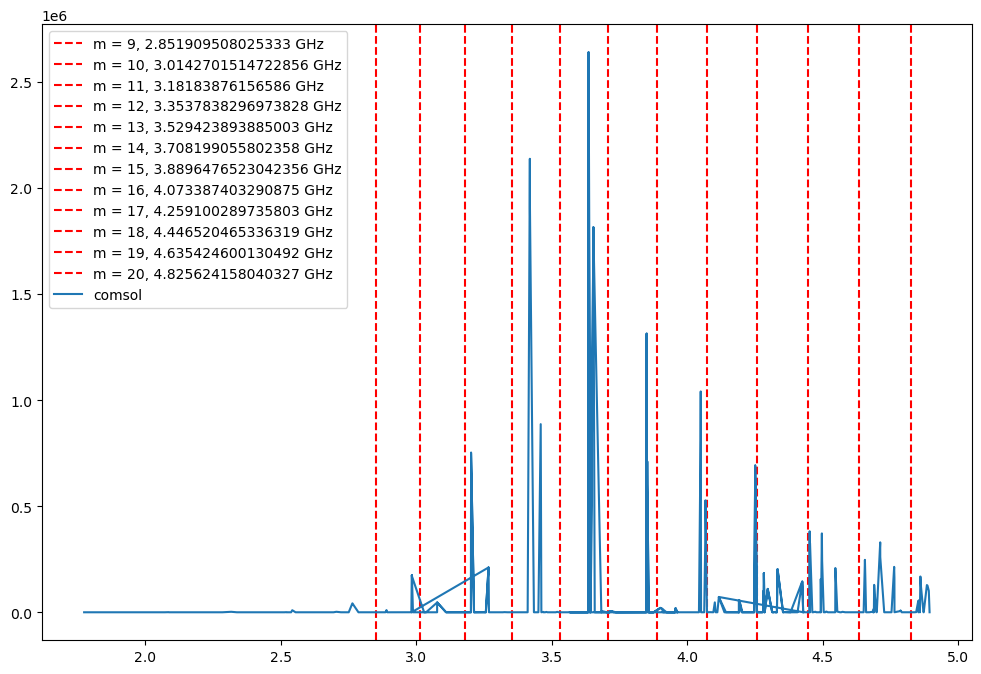

In [67]:
plt.figure(figsize = (12, 8))
for freq in test_TE['TE'][9:21].index:
    plt.axvline(x = test_TE['TE'][9:21][freq], ymin=0, ymax=3e6, 
                label = 'm = ' + str(test_TE['m'][9:21][freq]) + ', ' + str(test_TE['TE'][9:21][freq]) + ' GHz', 
                color = 'red', ls = 'dashed')
plt.plot(eigens_combined['Frequency (GHz)'], eigens_combined['Quality factor (1)'], label = 'comsol')
plt.legend()
#plt.scatter(test_TE['TE'][9:21], test_TE[9:21].index, label = 'TE predicted', color = 'red')
#plt.scatter(test_TE['TM'][9:21], test_TE[9:21].index, label = 'TM predicted', color = 'purple')

/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_16390/94160764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)


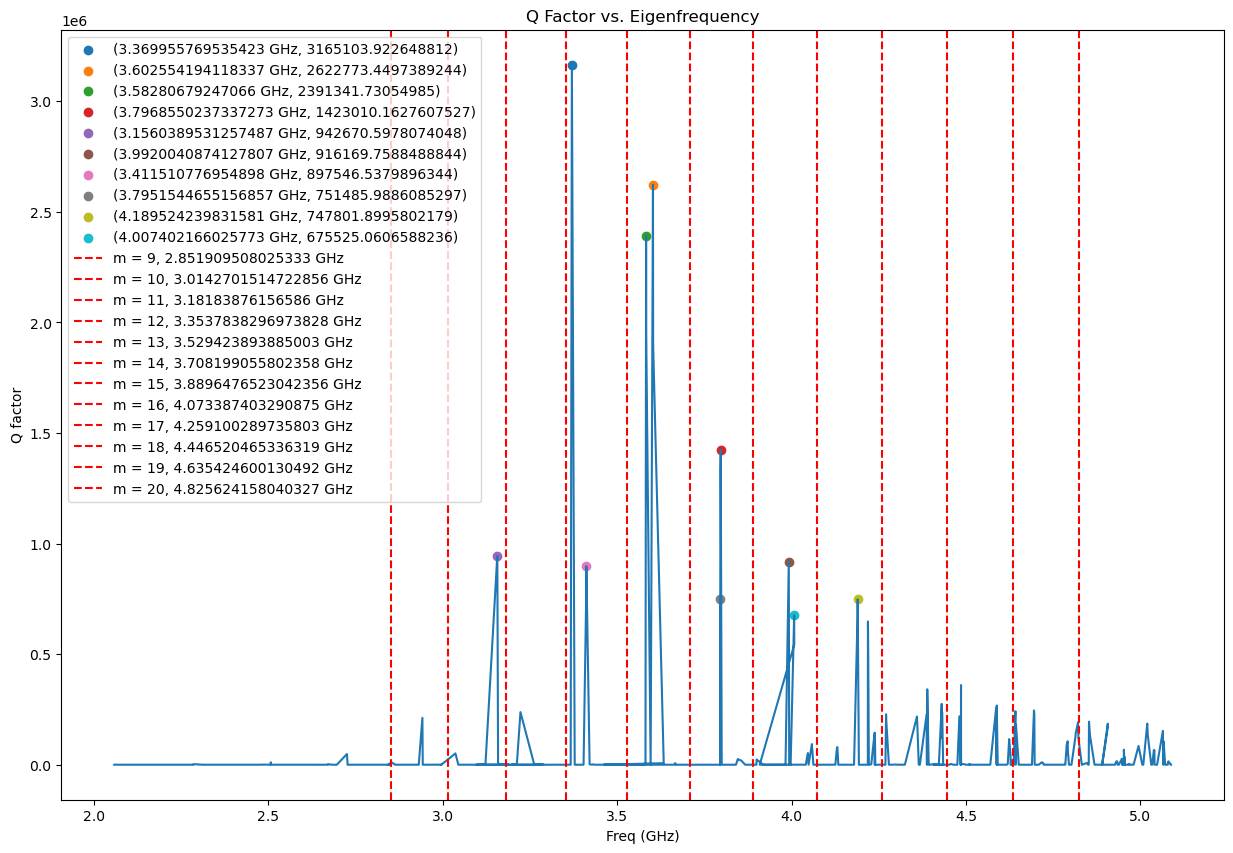

In [72]:

find_plot_Q_peaks_theory(CT9p8_newdim, n_peaks=10)
for freq in test_TE['TE'][9:21].index:
    plt.axvline(x = test_TE['TE'][9:21][freq], ymin=0, ymax=3e6, 
                label = 'm = ' + str(test_TE['m'][9:21][freq]) + ', ' + str(test_TE['TE'][9:21][freq]) + ' GHz', 
                color = 'red', ls = 'dashed')
#plt.plot(CT9p8_newdim['Frequency (GHz)'], CT9p8_newdim['Quality factor (1)'], label = 'comsol')
plt.legend()

/var/folders/ky/hnfmqvvd74x03rjxm1q6hf580000gn/T/ipykernel_16390/94160764.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q_freq_data['Freq rounded'] = Q_freq_data['Frequency (GHz)'].round(5)


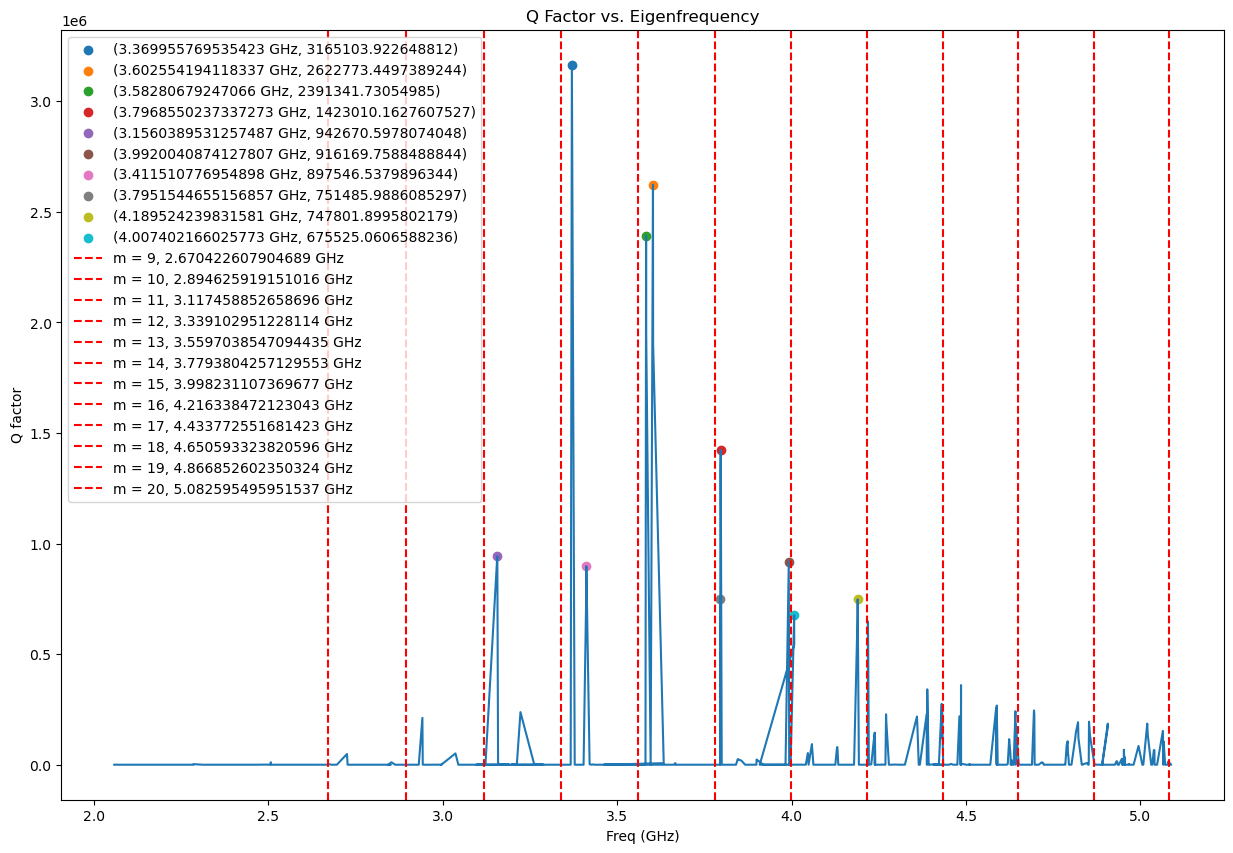

In [73]:

find_plot_Q_peaks_theory(CT9p8_newdim, n_peaks=10)
for freq in test_TE['TM'][9:21].index:
    plt.axvline(x = test_TE['TM'][9:21][freq], ymin=0, ymax=3e6, 
                label = 'm = ' + str(test_TE['m'][9:21][freq]) + ', ' + str(test_TE['TM'][9:21][freq]) + ' GHz', 
                color = 'red', ls = 'dashed')
#plt.plot(CT9p8_newdim['Frequency (GHz)'], CT9p8_newdim['Quality factor (1)'], label = 'comsol')
plt.legend()

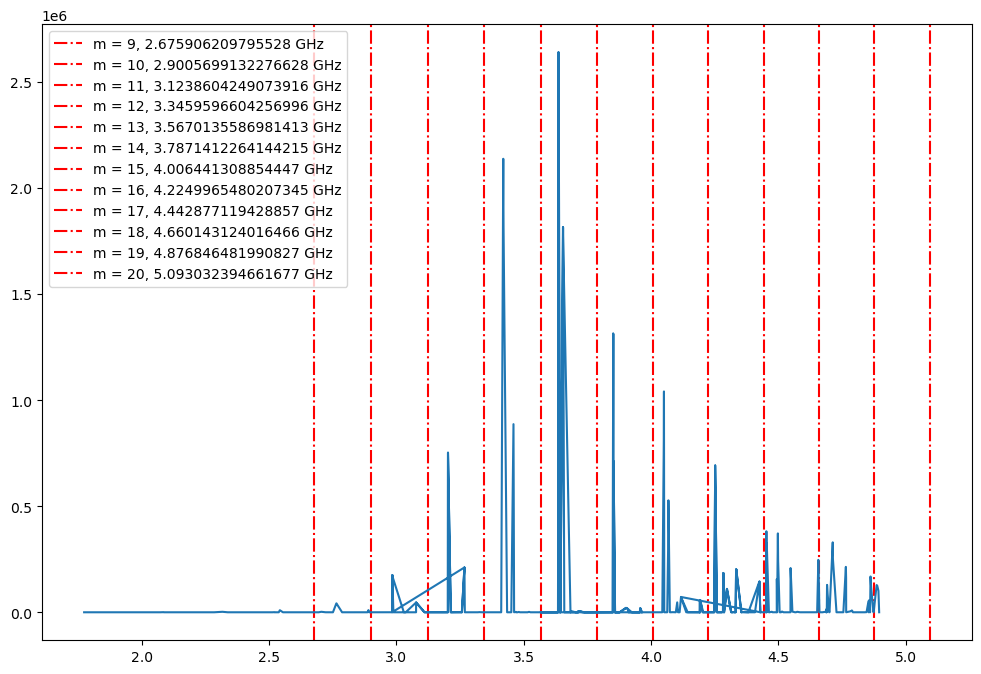

In [58]:
plt.figure(figsize = (12, 8))
for freq in test_TE['TM'][9:21].index:
    plt.axvline(x = test_TE['TM'][9:21][freq], ymin=0, ymax=3e6, 
                label = 'm = ' + str(test_TE['m'][9:21][freq]) + ', ' + str(test_TE['TM'][9:21][freq]) + ' GHz', 
                color = 'red', 
                ls = 'dashdot')
    plt.legend()
plt.plot(eigens_combined['Frequency (GHz)'], eigens_combined['Quality factor (1)'], label = 'comsol')

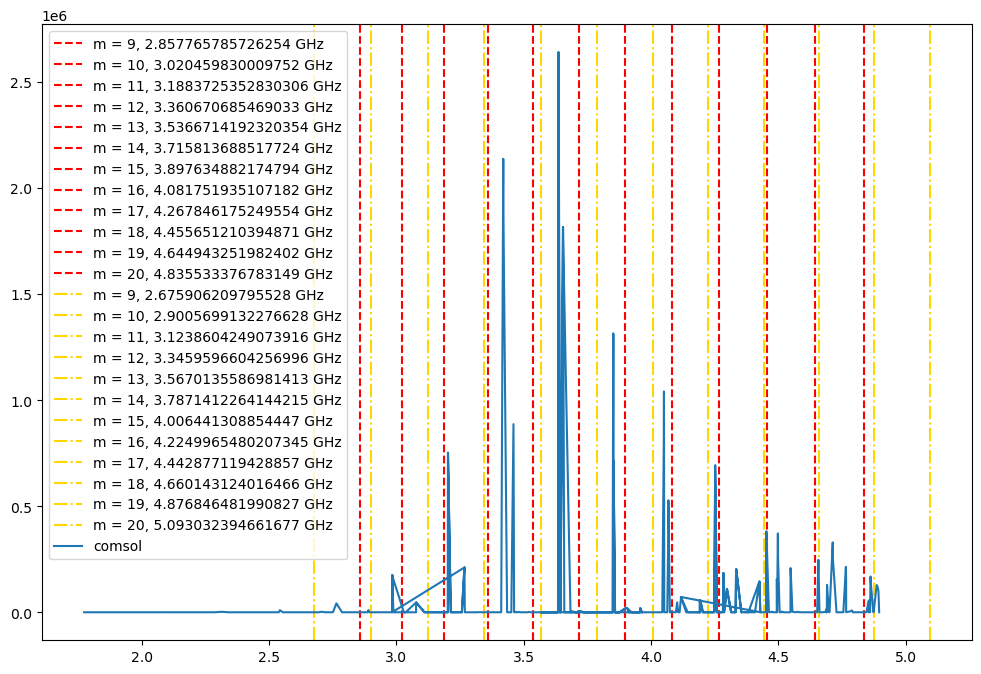

In [63]:
plt.figure(figsize = (12, 8))
for freq in test_TE['TE'][9:21].index:
    plt.axvline(x = test_TE['TE'][9:21][freq], ymin=0, ymax=3e6, 
                label = 'm = ' + str(test_TE['m'][9:21][freq]) + ', ' + str(test_TE['TE'][9:21][freq]) + ' GHz', 
                color = 'red', ls = 'dashed')
    
for freq in test_TE['TM'][9:21].index:
    plt.axvline(x = test_TE['TM'][9:21][freq], ymin=0, ymax=3e6, 
                label = 'm = ' + str(test_TE['m'][9:21][freq]) + ', ' + str(test_TE['TM'][9:21][freq]) + ' GHz', 
                color = 'gold', 
                ls = 'dashdot')
    

plt.plot(eigens_combined['Frequency (GHz)'], eigens_combined['Quality factor (1)'], label = 'comsol')
plt.legend()

In [ ]:
eigens_combined = pd.concat([E_cf2p5, E_cf3p5, E_cf4p0, E_cf4p5], ignore_index=True)